In [4]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

import init_creds as creds
import sys
from langchain_openai import AzureChatOpenAI
from langchain_core.messages import SystemMessage,HumanMessage, ToolMessage

from pydantic import BaseModel, Field
from typing import Literal


In [2]:
sys.path.insert(1, '../../')

# # Configure Azure OpenAI And OpenAI Embeddings
# AZURE_OPENAI_KEY = os.getenv('OPENAI_API_KEY')
# AZURE_OPENAI_ENDPOINT = os.getenv('AZURE_OPENAI_ENDPOINT')
# AZURE_OPENAI_API_VERSION = os.getenv('OPENAI_API_VERSION')


AZURE_OPENAI_KEY = creds.get_api_key()
AZURE_OPENAI_ENDPOINT = creds.get_endpoint()
AZURE_OPENAI_API_VERSION = "2025-04-01-preview"

if not AZURE_OPENAI_KEY:
    raise ValueError("No AZURE_OPENAI_KEY set for Azure OpenAI API")
if not AZURE_OPENAI_ENDPOINT:
    raise ValueError("No AZURE_OPENAI_ENDPOINT set for Azure OpenAI API")

llm = AzureChatOpenAI(
    model="gpt-4o-mini",
    azure_endpoint=AZURE_OPENAI_ENDPOINT,
    api_key=AZURE_OPENAI_KEY,
    api_version=AZURE_OPENAI_API_VERSION
)

In [5]:
from typing import Annotated, List
import operator


# Schema for structured output to use in planning
class Section(BaseModel):
    name: str = Field(
        description="Name for this section of the report.",
    )
    description: str = Field(
        description="Brief overview of the main topics and concepts to be covered in this section.",
    )


class Sections(BaseModel):
    sections: List[Section] = Field(
        description="Sections of the report.",
    )


# Augment the LLM with schema for structured output
planner = llm.with_structured_output(Sections)

In [6]:
from langgraph.types import Send


# Graph state
class State(TypedDict):
    topic: str  # Report topic
    sections: list[Section]  # List of report sections
    completed_sections: Annotated[
        list, operator.add
    ]  # All workers write to this key in parallel
    final_report: str  # Final report


# Worker state
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]


# Nodes
def orchestrator(state: State):
    """Orchestrator that generates a plan for the report"""

    # Generate queries
    report_sections = planner.invoke(
        [
            SystemMessage(content="Generate a plan for the report."),
            HumanMessage(content=f"Here is the report topic: {state['topic']}"),
        ]
    )

    return {"sections": report_sections.sections}


def llm_call(state: WorkerState):
    """Worker writes a section of the report"""

    # Generate section
    section = llm.invoke(
        [
            SystemMessage(
                content="Write a report section following the provided name and description. Include no preamble for each section. Use markdown formatting."
            ),
            HumanMessage(
                content=f"Here is the section name: {state['section'].name} and description: {state['section'].description}"
            ),
        ]
    )

    # Write the updated section to completed sections
    return {"completed_sections": [section.content]}


def synthesizer(state: State):
    """Synthesize full report from sections"""

    # List of completed sections
    completed_sections = state["completed_sections"]

    # Format completed section to str to use as context for final sections
    completed_report_sections = "\n\n---\n\n".join(completed_sections)

    return {"final_report": completed_report_sections}


# Conditional edge function to create llm_call workers that each write a section of the report
def assign_workers(state: State):
    """Assign a worker to each section in the plan"""

    # Kick off section writing in parallel via Send() API
    return [Send("llm_call", {"section": s}) for s in state["sections"]]



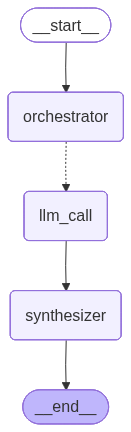

In [7]:
# Build workflow
orchestrator_worker_builder = StateGraph(State)

# Add the nodes
orchestrator_worker_builder.add_node("orchestrator", orchestrator)
orchestrator_worker_builder.add_node("llm_call", llm_call)
orchestrator_worker_builder.add_node("synthesizer", synthesizer)

# Add edges to connect nodes
orchestrator_worker_builder.add_edge(START, "orchestrator")
orchestrator_worker_builder.add_conditional_edges(
    "orchestrator", assign_workers, ["llm_call"]
)
orchestrator_worker_builder.add_edge("llm_call", "synthesizer")
orchestrator_worker_builder.add_edge("synthesizer", END)

# Compile the workflow
orchestrator_worker = orchestrator_worker_builder.compile()

# Show the workflow
display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))


In [ ]:
# Invoke
state = orchestrator_worker.invoke({"topic": "Create a report on LLM scaling laws"})

from IPython.display import Markdown
Markdown(state["final_report"])

In [9]:
final_state = {}
print("--- Graph Execution Log ---")
for event in orchestrator_worker.stream({"topic": "Create a report on LLM scaling laws"}):
    for node_name, value in event.items():
        print(f"Node invoked: {node_name}")
        final_state.update(value) # Keep track of the state

print("\n--- Final Report ---")
from IPython.display import Markdown
# The final state might be nested depending on how stream returns data, 
# but usually 'synthesizer' output will be in the last event or accumulated state.
# If using the accumulated final_state:
if "final_report" in final_state:
    display(Markdown(final_state["final_report"]))

--- Graph Execution Log ---
Node invoked: orchestrator
Node invoked: llm_call
Node invoked: llm_call
Node invoked: llm_call
Node invoked: llm_call
Node invoked: llm_call
Node invoked: llm_call
Node invoked: llm_call
Node invoked: synthesizer

--- Final Report ---


## Introduction to LLM Scaling Laws

Large Language Models (LLMs) have revolutionized the field of natural language processing (NLP) by demonstrating remarkable capabilities in understanding and generating human-like text. An essential aspect of improving these models lies in understanding LLM scaling laws, which describe how various performance metrics (e.g., accuracy, fluency, and versatility) improve as the size of the model, the volume of training data, or the computation resources allocated increase.

LLM scaling laws are empirical relationships that quantify the dependence of a model's performance on its scale. As researchers scale models up by increasing the number of parameters or the quantity of data used in training, they observe consistent patterns in performance improvements. These laws reveal that larger models tend to perform better across a wide range of tasks, illustrating a nonlinear relationship where doubling the model size does not simply double its performance but can lead to disproportionately significant gains.

Understanding LLM scaling laws is significant for several reasons. Firstly, they guide the allocation of resources in the model training process, allowing practitioners to make informed decisions on whether to invest in scaling up older models or focus on developing more efficient architectures. Secondly, they provide insights into the diminishing returns associated with scaling, helping to establish thresholds at which further increases in model complexity yield limited performance benefits. Lastly, scaling laws underpin the practical deployment of NLP applications, influencing approaches to model fine-tuning, transfer learning, and the design of new algorithms.

In summary, LLM scaling laws offer a critical framework for researchers and practitioners aiming to optimize and develop cutting-edge language models, directly impacting the advancement of NLP technologies across various domains. Understanding these laws ensures that resources are utilized efficiently while facilitating the continuous improvement of LLM capabilities.

---

## Historical Context

The journey of Large Language Models (LLMs) began in the mid-20th century, rooted in the early explorations of artificial intelligence and natural language processing. Initial models, such as ELIZA (1966) and SHRDLU (1970), showcased the potential of rule-based systems to understand and respond to human language. However, these early systems were limited by their reliance on predefined rules and lack of depth in understanding context.

In the 1980s and 1990s, the field began to shift towards statistical approaches. The introduction of n-gram models allowed for probabilistic language modeling, paving the way for more sophisticated systems. This period saw foundational research by authors like Claude Shannon and later the development of the Hidden Markov Model (HMM), which advanced speech recognition and parsing techniques.

The advent of neural networks in the late 1990s and early 2000s marked a monumental turning point. Research papers such as "A Neural Probabilistic Language Model" by Bengio et al. (2003) introduced the concept of using deep learning for language processing, setting the stage for future developments. The transition from shallow neural networks to deep architectures facilitated the capture of more complex syntactic and semantic patterns in language.

A significant breakthrough occurred in 2013 with the introduction of Word2Vec by Mikolov et al. This approach utilized word embeddings, allowing the model to understand the meaning of words based on their context in a more nuanced way. This innovation added depth to the capabilities of language models, resulting in significantly improved performance in various NLP tasks.

With the emergence of Transformers in 2017, detailed in the paper "Attention is All You Need" by Vaswani et al., the landscape of LLMs transformed dramatically. The self-attention mechanism allowed models to weigh the significance of different words in relation to each other, leading to superior understanding and generation of human-like text. The architecture's ability to parallelize training further accelerated the pace of development in the field.

The scaling hypothesis, reinforced by works such as "Scaling Laws for Neural Language Models" (Kaplan et al., 2020), emphasized the importance of model size and training data. This led to the realization that increasing the number of parameters and training on larger datasets could consistently enhance model performance. It was subsequently observed that larger models, such as GPT-3, exhibited emergent behaviors that surpassed their predecessors in both fluency and comprehension.

In summary, the evolution of LLMs from the deterministic and rule-based systems of the early days to the current state of sophisticated transformer-based architectures illustrates a profound shift in how machines engage with human language. Key milestones, breakthroughs, and influential research have collectively driven advancements in the field, fostering the powerful LLMs we see today.

---

## Key Concepts in Scaling Laws

The study of scaling laws in large language models (LLMs) revolves around several fundamental concepts that dictate how model size, the amount of training data, and compute resources interact to influence performance. Understanding these concepts is crucial for optimizing the efficiency and effectiveness of LLMs.

### Model Size

Model size refers to the number of parameters in a language model. As LLMs grow in size, they generally exhibit enhanced capabilities in terms of understanding and generating human-like text. Scaling up the number of parameters can lead to improved performance, allowing the model to capture a broader range of linguistic patterns and nuances.

### Training Data Size

The amount of training data directly influences model performance. Larger datasets typically provide models with a richer set of information to learn from, resulting in better generalization and performance. The relationship between training data size and model size is critical; scaling up model parameters necessitates a corresponding increase in training data to fully utilize the model's capacity.

### Compute Resources

Compute resources encompass the hardware and energy required to train and deploy LLMs. As model size and data complexity increase, the demand for computational power rises exponentially. This often leads practitioners to assess cost-effectiveness and efficiency of the infrastructure to ensure optimal resource allocation during the training process.

### Interactions and Performance Metrics

The interaction between model size, training data size, and compute resources is complex but can be summarized through performance metrics. One key metric is performance gain per parameter, which evaluates the efficiency of adding new parameters to the model. This metric helps to identify diminishing returns as models scale, guiding decisions on the feasible limits of model expansion.

### Performance Gains per Parameter

When considering the scalability of LLMs, the performance gain per parameter metric serves as an important barometer. This metric typically decreases as models grow larger, indicating that the initial increments in model size yield significant performance improvements. However, after a certain point, the additional parameters contribute less to overall model capability, demonstrating the need for a balanced approach in scaling efforts.

In summary, the scalability of LLMs is influenced by a delicate interplay between model size, training data, and compute resources. Understanding these foundational concepts is essential for developing efficient and powerful language models.

---

## Empirical Evidence and Experiments

Extensive empirical research has been conducted to analyze the scaling laws associated with large language models (LLMs). Such studies have illuminated the relationship between model size, dataset size, and performance metrics. Below, we summarize significant findings from key models, including GPT-3, T5, and others.

### GPT-3

Researchers at OpenAI conducted a detailed analysis of GPT-3, focusing on its ability to generalize based on model size and training data. In their paper, they revealed that doubling the number of parameters from 2.7 billion to 175 billion led to an approximate performance improvement across various natural language processing (NLP) tasks. The scaling laws indicated that performance improvements continued to follow a power-law trend, suggesting that larger models yield diminishing returns but still meaningful gains, particularly in zero-shot and few-shot settings.

### T5

The T5 (Text-to-Text Transfer Transformer) model provided another significant touchpoint in analyzing scaling laws. Research demonstrated that as the number of parameters increased, so did the model's ability to handle a variety of NLP tasks when framed as text-to-text problems. Experiments compared T5 with fewer parameters against larger versions, showing that the larger T5 models far outperformed smaller ones across diverse benchmarks, including GLUE and SuperGLUE. The findings indicated not only performance gains but also reinforced the hypothesis that dataset size plays a critical role in enhancing model effectiveness.

### BERT and Variants

Variations of the Bidirectional Encoder Representations from Transformers (BERT) also contributed valuable insights into LLM scaling. Studies comparing the original BERT model with its larger counterparts, such as RoBERTa, demonstrated that larger models trained on more extensive datasets consistently outperformed smaller models on tasks across multiple benchmarks. The research highlighted that pre-training strategies and optimization techniques influenced the scaling behavior.

### Scaling Laws as Predictive Models

Empirical studies have repeatedly validated the predictive nature of scaling laws. Matthews et al. (2020) introduced analytical frameworks that allow researchers to estimate performance improvements based on model size prior to training. Their work suggested that scaling laws could help in forecasting not only the performance of theoretical models but also the resource allocation needed for future training endeavors.

### Summary of Findings

The body of empirical evidence amassed from various studies indicates significant relationships between parameter count, dataset volume, and model performance. Despite the occurrence of diminishing returns at larger scales, LLMs consistently exhibit improvements that warrant ongoing increases in scale. As empirical work continues in this domain, further clarification on how to balance scaling behaviors with practical resource considerations remains a pivotal area of focus.

---

## Challenges and Limitations

The journey toward scaling large language models (LLMs) is fraught with numerous challenges and limitations that can significantly impact both their development and deployment.

### Computational Costs
One of the most pressing challenges associated with LLMs is the astronomical computational cost involved in their training and operation. As models increase in size—often exceeding billions of parameters—the resource requirements multiply. This includes not only the hardware necessary for training, such as GPUs and TPUs, but also the associated energy consumption. Consequently, the financial burden can be substantial, creating barriers for smaller organizations and fostering a technology divide within the field.

### Diminishing Returns
As researchers and developers scale up LLMs, they often encounter diminishing returns in performance improvements relative to the increase in size and complexity. While initial increases in model size may yield significant gains in performance on various natural language tasks, subsequent expansions may contribute marginally to enhancements in capabilities. This raises questions about whether investments in more massive models are justified, especially when alternative approaches or model optimizations could yield superior or more efficient outcomes.

### Ethical Considerations
The ethical implications surrounding LLM scaling are multifaceted and increasingly important. Issues of accountability, transparency, and the potential for misuse are amplified as models grow in sophistication and capability. The risk of generating misleading or harmful content poses challenges to developers and policymakers alike. Moreover, ensuring that ethical guidelines are aligned with the rapid advancements in LLM technology remains a significant hurdle that demands ongoing attention.

### Model Biases and Fairness
As LLMs are trained on vast datasets sourced from the internet, they often inadvertently learn and perpetuate biases present in their training data. This has far-reaching implications for fairness, particularly in applications where decisions impact individuals or communities. Scaling LLMs brings forth the risk of amplifying these biases, leading to discriminatory outcomes in various contexts, from hiring practices to law enforcement. Addressing these biases requires ongoing research into fairness and representativeness during the model development process, as well as mechanisms for bias detection and mitigation.

In summary, while the scaling of LLMs presents exciting opportunities for advancements in artificial intelligence, it is essential to navigate through these challenges and limitations with a conscious and proactive approach to ensure responsible and equitable AI development.

---

## Future Directions and Trends

As large language models (LLMs) continue to evolve, several significant trends are anticipated in the coming years. These trends include advancements in scaling laws, innovative training approaches, and an increasing focus on interdisciplinary applications.

### Advancements in Scaling Laws

Research into scaling laws for LLMs is likely to deepen, focusing on the relationship between model size, training data, and performance. Future studies may explore diminishing returns at large scales, questioning whether continual increases in model size will yield proportional improvements in capabilities. Insights gained may lead to more efficient architectures, optimizing resource utilization and performance without excessively increasing computational costs.

### Innovative Training Approaches

Future training methodologies may incorporate unsupervised learning techniques that leverage vast amounts of unstructured data. Hybrid training paradigms that combine supervised, unsupervised, and reinforcement learning could become mainstream. Additionally, advancements in few-shot and zero-shot learning will likely enhance the adaptability of LLMs, allowing them to perform well on specific tasks with minimal training data. Techniques such as curriculum learning or progressive learning may also gain traction, focusing on how models can learn more effectively over time.

### Interdisciplinary Applications

The applicability of LLMs across various disciplines is expected to grow. Future research may target medical, legal, and scientific fields, developing domain-specific models capable of understanding complex, specialized language. Collaborative efforts between computer scientists and experts from other domains may lead to tailored LLMs that can assist in decision-making, diagnostics, and creative endeavors, integrating nuanced knowledge from these areas.

### Ongoing Research Areas

Research into interpretability and bias mitigation will likely remain a priority as LLMs become more prevalent in impactful applications. Techniques to decode how models make predictions and to ensure fairness in outputs will be crucial as ethical considerations in AI continue to rise. Additionally, advancements in model efficiency, such as the development of quantization and distillation methods, will support the deployment of LLMs in resource-constrained environments.

### Conclusion

The future of LLM research is poised for exciting developments, blending novel theoretical insights with practical applications across disciplines. As researchers address scalability, improve training techniques, and explore interdisciplinary uses, the potential impact of LLMs on society and various fields will continue to expand, shaping the next generation of artificial intelligence capabilities.

---

## Conclusion and Summary

The exploration of Large Language Model (LLM) scaling laws has revealed several critical findings that underscore their significance in advancing artificial intelligence. Key insights from this report highlight the direct relationship between model size, data volume, and performance. Notably, as LLMs scale, they tend to demonstrate improved language understanding, generation capabilities, and adaptability across diverse tasks. This understanding is essential for guiding future model development and optimizing resource allocation.

Furthermore, the analysis emphasizes the diminishing returns observed in performance gains at extreme scales, suggesting that researchers must balance model complexity and computational efficiency. The findings point to a need for innovative techniques in model training and architecture optimization to maximize utility while minimizing costs.

The implications of these insights extend beyond theoretical understanding; they hold practical importance for researchers and practitioners. Effective application of LLM scaling laws can inform strategic decisions regarding infrastructure investments, data collection strategies, and model deployment. As the demand for more sophisticated AI systems continues to grow, leveraging scaling laws will be pivotal in shaping the future landscape of machine learning.

In summary, recognizing and applying LLM scaling laws is vital for the ongoing evolution of AI technologies. Moving forward, researchers must remain vigilant in exploring new methodologies that can refine and expand upon these principles, ensuring that the benefits of LLMs are realized in practical, sustainable ways.